In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import *
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from numpy import argmax
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from yellowbrick.classifier import ROCAUC, ClassificationReport, PrecisionRecallCurve
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML6.1%20clustering/data/mall_customers_clustering.csv', index_col=0)
df.head()

,CustomerID,Genre,Age,Income,Score
0,1,Male,19,15000,0.39
1,2,Male,21,15000,0.81
2,3,Female,20,16000,0.06
3,4,Female,23,16000,0.77
4,5,Female,31,17000,0.40


<Axes: xlabel='Income', ylabel='Score'>

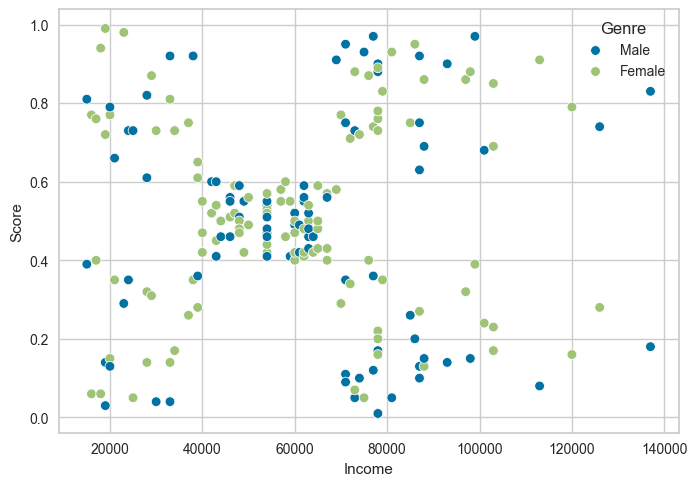

In [3]:
sns.scatterplot(x='Income' , y='Score',data=df , hue='Genre')

In [4]:
x = df.drop(["CustomerID"], axis=1)
X = pd.get_dummies(x)

In [5]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3, random_state=42).fit(X)

In [6]:
y_kmeans = k_means.labels_

In [9]:
centers = k_means.cluster_centers_

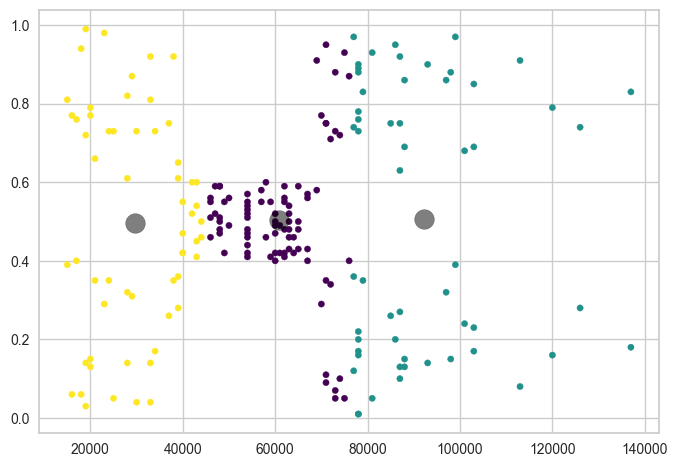

In [21]:
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

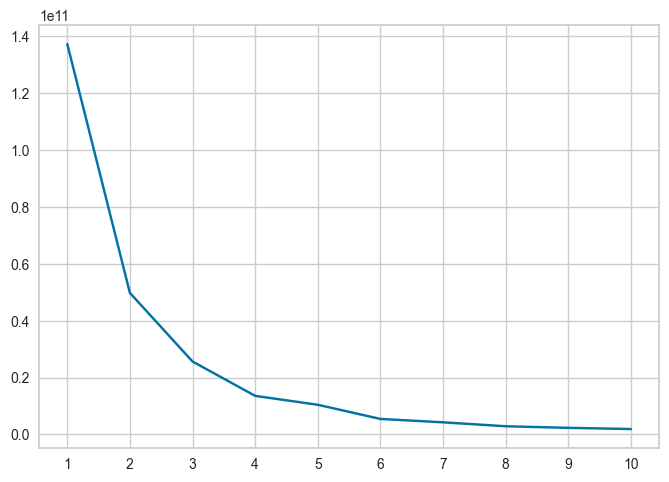

In [13]:
wcss = []
for i in range(1,11):
	k_means = KMeans(n_clusters=i,random_state=42)
	k_means.fit(X)
	wcss.append(k_means.inertia_)
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
_ = plt.show()

In [14]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X)

In [35]:
centers = k_means.cluster_centers_

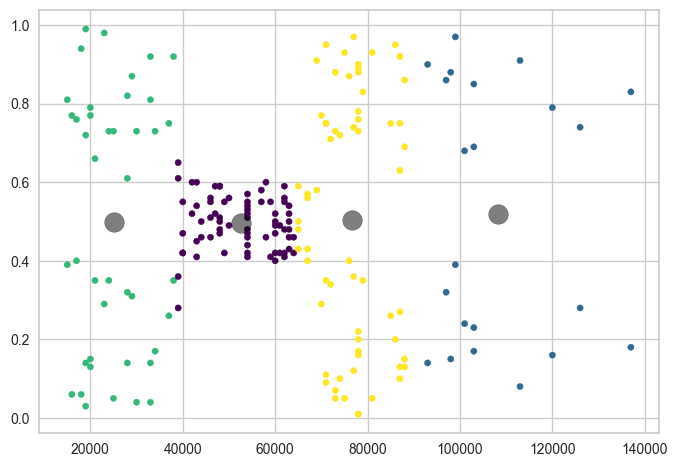

In [36]:
plt.scatter(x.Income, x.Score, c=k_means.labels_, s=20, cmap='viridis')
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

In [37]:
k_means = KMeans(n_clusters=8, random_state=42).fit(X)

In [38]:
centers = k_means.cluster_centers_

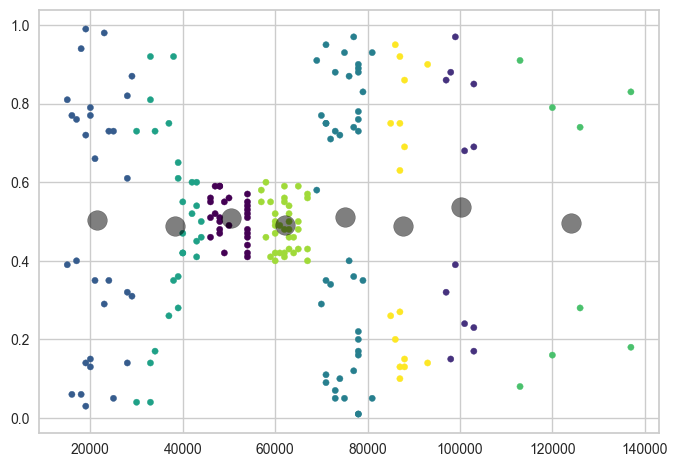

In [39]:
plt.scatter(x.Income, x.Score, c=k_means.labels_, s=20, cmap='viridis')
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Age,Income,Score,Genre_Female,Genre_Male
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405


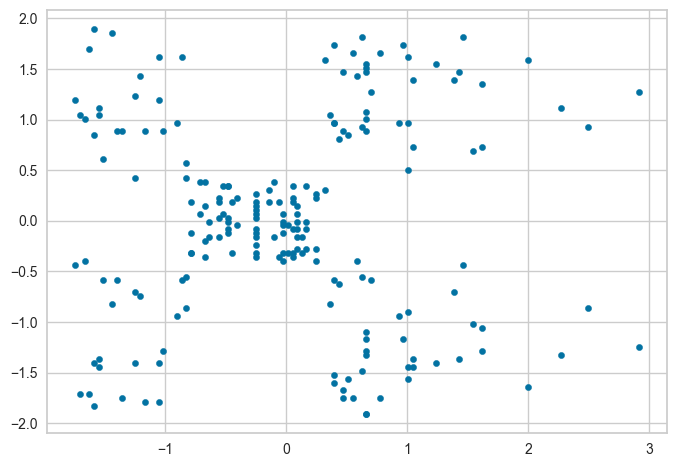

In [43]:
plt.scatter(X_scaled.Income, X_scaled.Score, s=20)
plt.show()

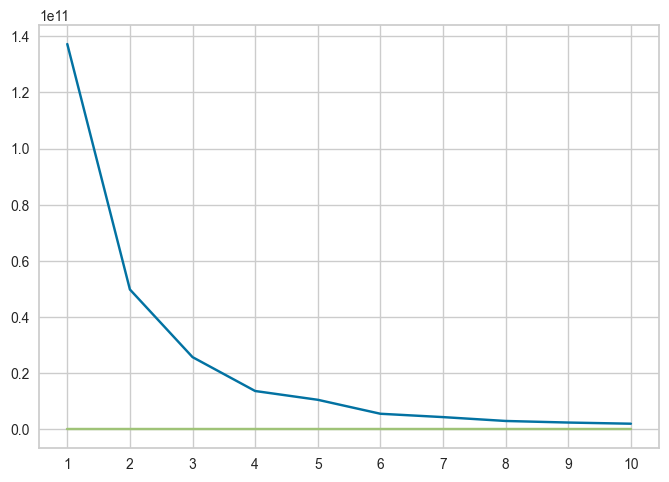

In [50]:
unscaled, scaled = [], []
for i in range(1,11):
	unscaled.append(KMeans(n_clusters=i,random_state=42).fit(X).inertia_)
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X_scaled).inertia_)
plt.plot(range(1,11),unscaled)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

In [55]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X_scaled)

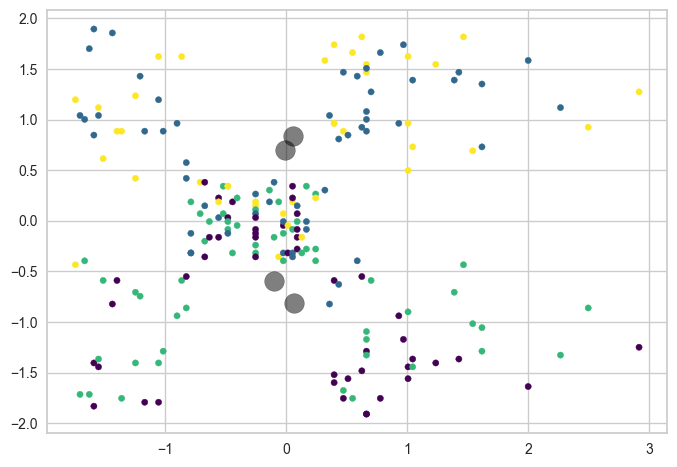

In [59]:
centers = k_means.cluster_centers_
plt.scatter(X_scaled.Income, X_scaled.Score, c=k_means.labels_, s=20, cmap='viridis')
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

In [60]:
X_flat = X_scaled.drop(["Age", "Genre_Female", "Genre_Male"], axis=1)
X_flat.head()

,Income,Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


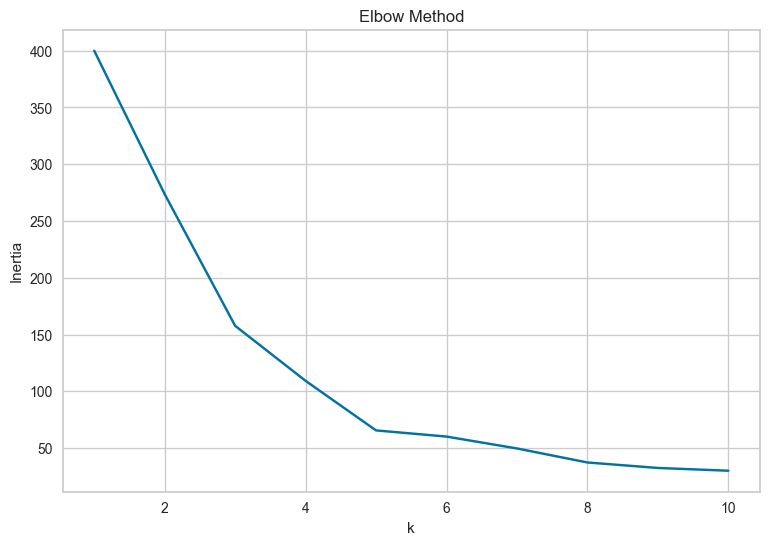

In [72]:
plt.figure(figsize=(9, 6))
inertia = []
for i in range(1, 11):
    inertia.append(KMeans(n_clusters=i, random_state=42).fit(X_flat).inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [73]:
k_means = KMeans(n_clusters=5, random_state=42).fit(X_flat)

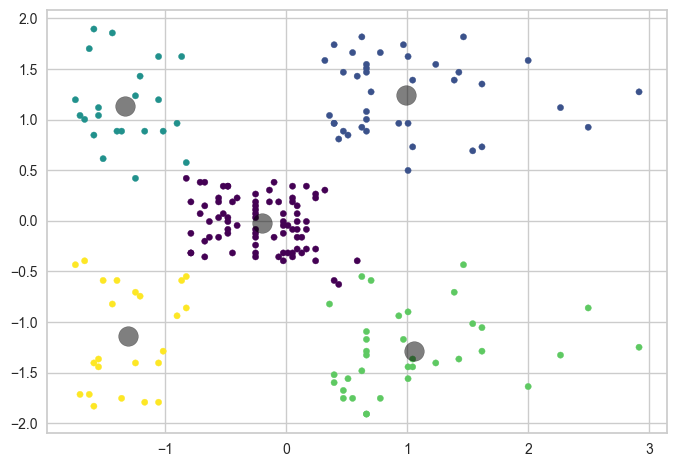

In [75]:
centers = k_means.cluster_centers_
plt.scatter(X_scaled.Income, X_scaled.Score, c=k_means.labels_, s=20, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.show()

In [76]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X_scaled)

In [77]:
from scipy.cluster.hierarchy import dendrogram

In [78]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

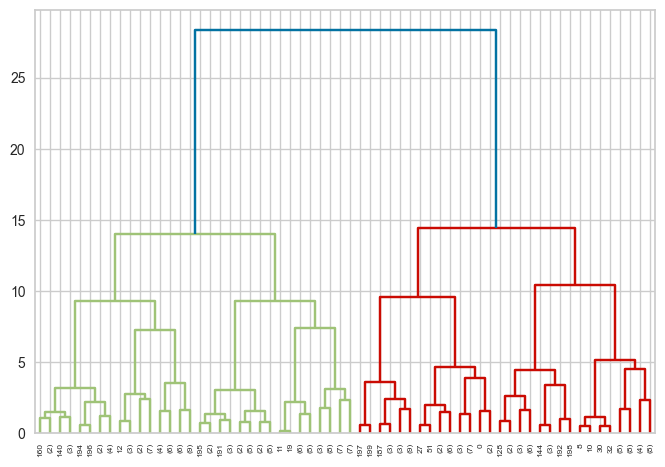

In [79]:
plot_dendrogram(model, truncate_mode="level", p=5)

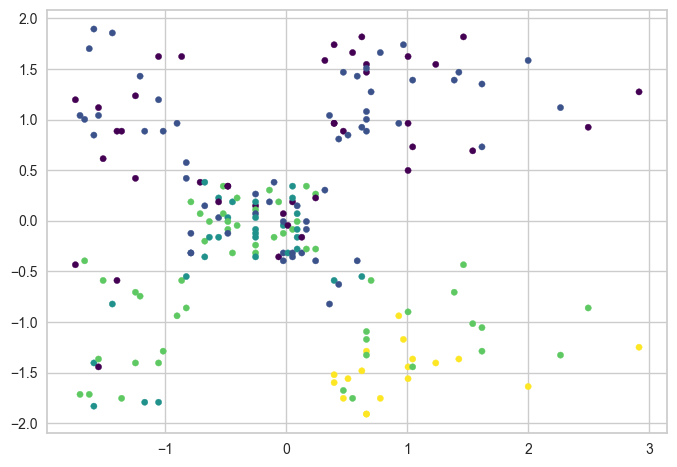

In [80]:
agg_clustering = AgglomerativeClustering(n_clusters=5).fit(X_scaled)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

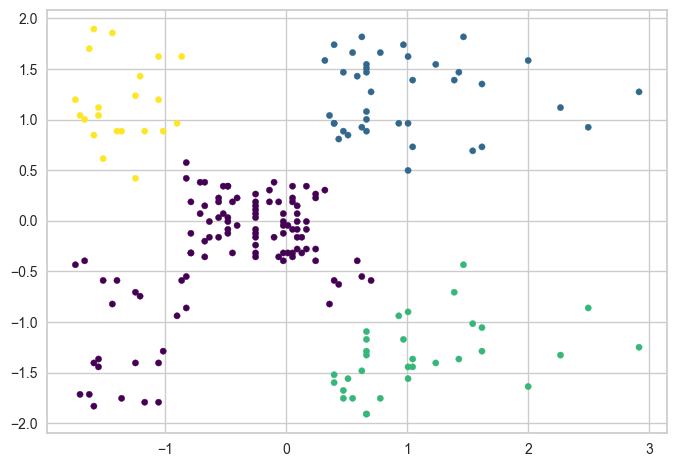

In [81]:
agg_clustering = AgglomerativeClustering(n_clusters=4).fit(X_flat)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

In [82]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

In [83]:
n_clusters_ = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)

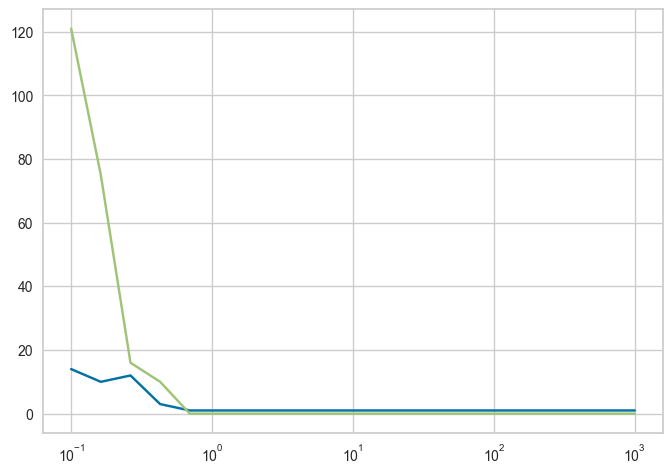

In [84]:
clusters, noise = [], []
for i in np.logspace(-1, 3, 20):
  db = DBSCAN(eps=i, min_samples=3).fit(X_flat)
  y_db = db.labels_

  clusters.append(len(set(y_db)) - (1 if -1 in y_db else 0))
  noise.append(list(y_db).count(-1))

plt.plot(np.logspace(-1, 3, 20),clusters)
plt.plot(np.logspace(-1, 3, 20),noise)
plt.xscale('log')
_ = plt.show()

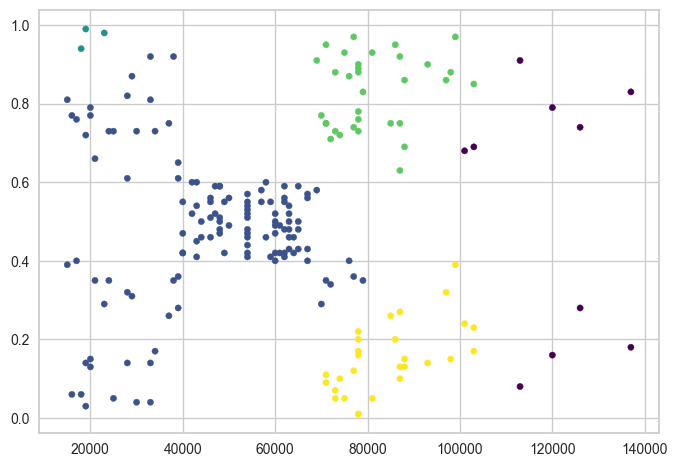

In [85]:
db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

plt.scatter(X.Income, X.Score, c=y_db, s=20, cmap='viridis')

## Практическая работа

### 1. Примеры точек выборки для каждого класса

In [87]:
kmeans = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
X['Cluster'] = kmeans.labels_

In [88]:
for i in range(4):
    print(f"\nКластер {i}:")
    print(X[X['Cluster'] == i][['Age', 'Income', 'Score', 'Genre_Female', 'Genre_Male']].head(3))
    print(f"Средние значения:")
    print(X[X['Cluster'] == i][['Age', 'Income', 'Score']].mean())


Кластер 0:
    Age  Income  Score  Genre_Female  Genre_Male
8    64   19000   0.03         False        True
10   67   19000   0.14         False        True
14   37   20000   0.13         False        True
Средние значения:
Age          49.437500
Income    62416.666667
Score         0.292083
dtype: float64

Кластер 1:
   Age  Income  Score  Genre_Female  Genre_Male
3   23   16000   0.77          True       False
5   22   17000   0.76          True       False
7   23   18000   0.94          True       False
Средние значения:
Age          28.392857
Income    60428.571429
Score         0.681786
dtype: float64

Кластер 2:
   Age  Income  Score  Genre_Female  Genre_Male
2   20   16000   0.06          True       False
4   31   17000   0.40          True       False
6   35   18000   0.06          True       False
Средние значения:
Age          47.803571
Income    58071.428571
Score         0.348750
dtype: float64

Кластер 3:
    Age  Income  Score  Genre_Female  Genre_Male
0    19   15000  

Кластер 0 (пожилые мужчины, низкий скор): 49 лет, высокий доход (62.4K), низкие траты (0.29) — "экономные пенсионеры"

Кластер 1 (молодые женщины, высокий скор): 28 лет, высокий доход (60.4K), высокие траты (0.68) — "платежеспособные молодые"

Кластер 2 (средний возраст женщины, низкий скор): 48 лет, доход ниже (58.1K), траты низкие (0.35) — "средний класс с низкой активностью"

Кластер 3 (молодые мужчины, высокий скор): 28 лет, высокий доход (62K), высокие траты (0.72) — "молодые активные мужчины"

Вывод: Наиболее привлекательные сегменты — кластеры 1 и 3 (молодые с высокими тратами). Кластер 0 требует удержания, кластер 2 — стимулирования покупок.

### 2. Другие пары признаков 

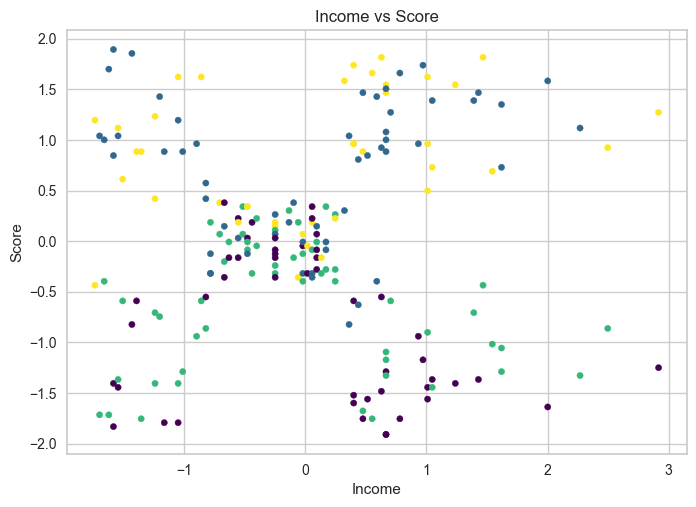

In [98]:
plt.scatter(X_scaled.Income, X_scaled.Score, c=kmeans.labels_, cmap='viridis', s=20)
plt.xlabel('Income')
plt.ylabel('Score')
plt.title('Income vs Score')
plt.show()

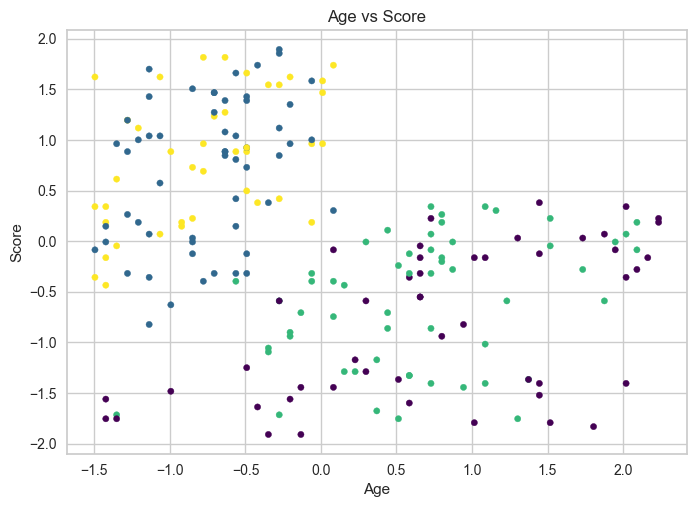

In [99]:
plt.scatter(X_scaled.Age, X_scaled.Score, c=kmeans.labels_, cmap='viridis', s=20)
plt.xlabel('Age')
plt.ylabel('Score')
plt.title('Age vs Score')
plt.show()

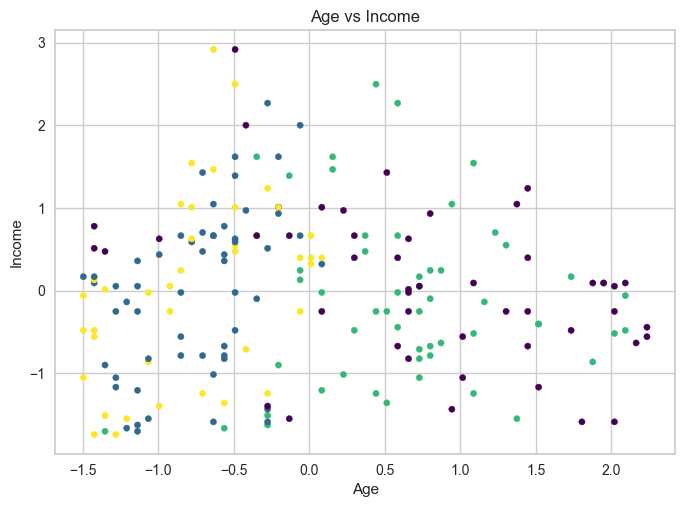

In [101]:
plt.scatter(X_scaled.Age, X_scaled.Income, c=kmeans.labels_, cmap='viridis', s=20)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.show()

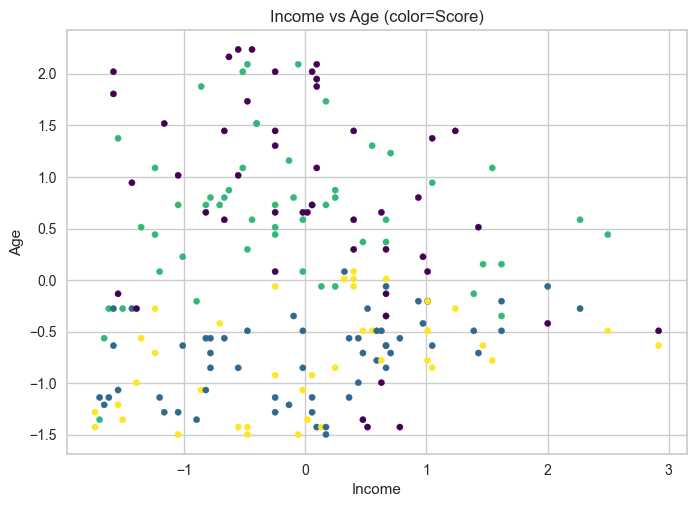

In [105]:
sc = plt.scatter(X_scaled.Income, X_scaled.Age, c=kmeans.labels_, cmap='viridis', s=20)
plt.xlabel('Income')
plt.ylabel('Age')
plt.title('Income vs Age (color=Score)')
plt.show()

Кластеры перемешаны на всех парах признаков, что подтверждает необходимость использования всех признаков для корректной кластеризации. Наиболее значимые — Income Score и Age Score.

### 3. Другой датасет

In [106]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML6.1%20clustering/data/credit_card_clustering.csv', index_col=0)
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [117]:
df_clean = df.dropna()
X = df_clean.copy()

In [118]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

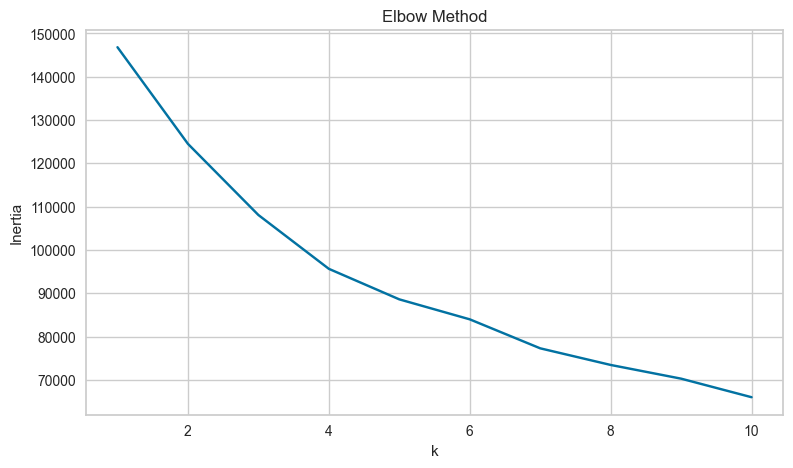

In [119]:
plt.figure(figsize=(9, 5))
inertia = [KMeans(n_clusters=i, random_state=42).fit(X_scaled).inertia_ for i in range(1, 11)]
plt.plot(range(1, 11), inertia)
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [124]:
kmeans = KMeans(n_clusters=5, random_state=42).fit(X_scaled)
df_clean['Cluster'] = kmeans.labels_

/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_66868/2876786233.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = kmeans.labels_


In [127]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print(pd.DataFrame(centers, columns=X.columns))

       BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
0  4641.965560           0.968678    490.660836        307.530810   
1   753.256400           0.933753    958.419517        365.417077   
2  5567.142164           0.957273  24957.905000      18186.875667   
3  1095.147276           0.822151    283.638140        228.267982   
4  2562.599722           0.984471   4500.118185       2936.678051   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0              183.219525   4632.975715             0.285747   
1              593.411378    182.413029             0.867655   
2             6771.029333   1858.844605             0.910556   
3               55.582348    624.536549             0.165951   
4             1564.170950    492.627263             0.950733   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.135138                          0.182657   
1                    0.221388                          0.718116   

In [128]:
for i in range(5):
    print(f"\nКластер {i}:")
    print(df_clean[df_clean['Cluster'] == i][['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']].head(3))
    print(df_clean[df_clean['Cluster'] == i][['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']].mean())


Кластер 0:
             BALANCE  PURCHASES  CREDIT_LIMIT
CUST_ID                                      
C10002   3202.467416       0.00        7000.0
C10016   6886.213231    1611.70        8000.0
C10024   3800.151377    4248.35        9000.0
BALANCE         4641.965560
PURCHASES        490.660836
CREDIT_LIMIT    7616.861396
dtype: float64

Кластер 1:
             BALANCE  PURCHASES  CREDIT_LIMIT
CUST_ID                                      
C10003   2495.148862     773.17        7500.0
C10006   1809.828751    1333.28        1800.0
C10008   1823.652743     436.20        2300.0
BALANCE          753.631341
PURCHASES        957.694081
CREDIT_LIMIT    3688.895834
dtype: float64

Кластер 2:
              BALANCE  PURCHASES  CREDIT_LIMIT
CUST_ID                                       
C10144   19043.138560   22009.92       18000.0
C10284    5131.319584   32539.78       11500.0
C10523   13479.288210   41050.40       17000.0
BALANCE          5567.142164
PURCHASES       24957.905000
CREDIT_LIMIT 

Оптимальное количество кластеров — 5, так как обеспечивает более детальную сегментацию. Выделяются ключевые группы: VIP-клиенты (кластер 2 с максимальными покупками), активные покупатели (кластер 4), умеренные (кластер 1), пассивные (кластер 3) и кредитные пользователи (кластер 0). 3 кластера дают слишком обобщенную картину.

### 4. Разные методы расчета расстояния между кластерами

Дальше идет иерархическая кластеризация AgglomerativeClustering.  
Строится дендрограмма, чтобы увидеть, как объекты и группы сливаются.

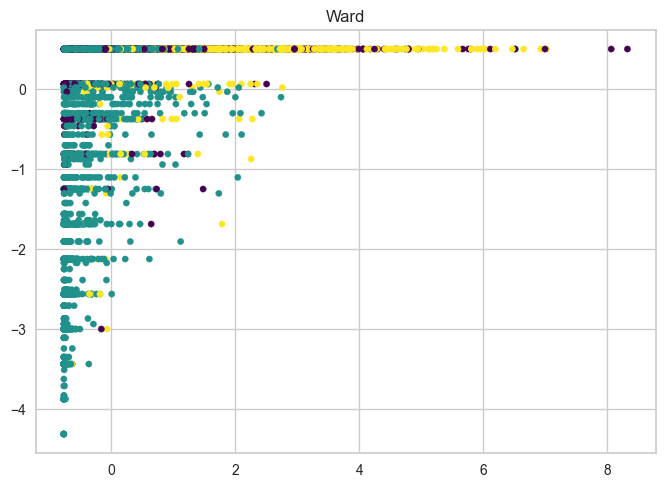

In [131]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X_scaled)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_, cmap='viridis', s=20)
plt.title('Ward')
plt.show()

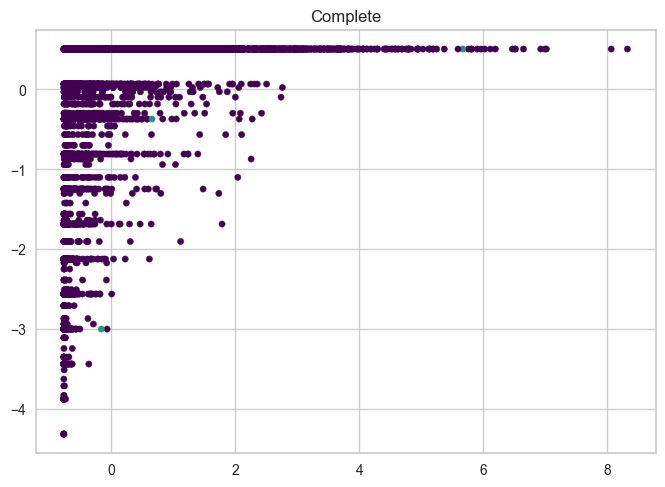

In [132]:
model = AgglomerativeClustering(n_clusters=3, linkage='complete').fit(X_scaled)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_, cmap='viridis', s=20)
plt.title('Complete')
plt.show()

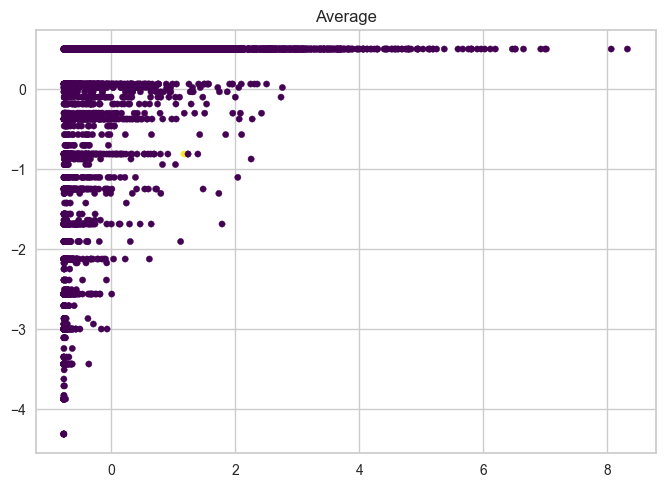

In [133]:
model = AgglomerativeClustering(n_clusters=3, linkage='average').fit(X_scaled)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_, cmap='viridis', s=20)
plt.title('Average')
plt.show()

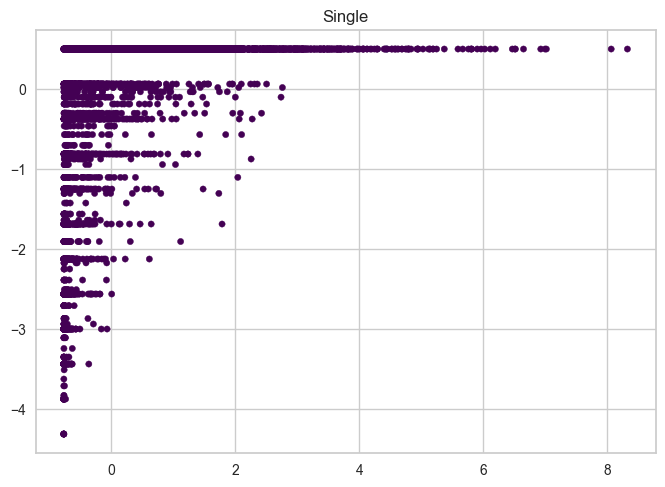

In [134]:
model = AgglomerativeClustering(n_clusters=3, linkage='single').fit(X_scaled)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_, cmap='viridis', s=20)
plt.title('Single')
plt.show()

In [136]:
methods = ['ward', 'complete', 'average', 'single']
for idx, method in enumerate(methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=method).fit(X_scaled)
    print(f"\n{method}: {np.bincount(model.labels_)}")


ward: [3168 4346 1122]

complete: [8612   23    1]

average: [8634    1    1]

single: [8634    1    1]


Вывод: Только Ward дает сбалансированное разделение (3168, 4346, 1122). Complete, average и single сливают почти все точки в один кластер — неприменимы для этих данных.

### 5. Вычисляем метрику WCSS и соотносим результаты

In [137]:
db = DBSCAN(eps=0.5, min_samples=5).fit(X_scaled)
y_db = db.labels_

In [138]:
n_clusters = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise = list(y_db).count(-1)

In [140]:
wcss_db = 0
for i in range(n_clusters):
    cluster_points = X_scaled[y_db == i]
    center = cluster_points.mean(axis=0)
    wcss_db += np.sum((cluster_points - center) ** 2)

In [141]:
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_scaled)

print(f"DBSCAN: кластеров={n_clusters}, шум={n_noise}, WCSS={wcss_db:.0f}, силуэт={silhouette_score(X_scaled[y_db!=-1], y_db[y_db!=-1]):.3f}")
print(f"K-Means: WCSS={kmeans.inertia_:.0f}, силуэт={silhouette_score(X_scaled, kmeans.labels_):.3f}")

DBSCAN: кластеров=36, шум=6488, WCSS=6603, силуэт=-0.311
K-Means: WCSS=108086, силуэт=0.247


DBSCAN нашёл 36 маленьких кластеров и пометил 6488 точек (≈75%) как шум. Это значит, что алгоритм счёл большую часть данных «непохожей ни на что». Отрицательный силуэт (-0.311) говорит, что разбиение плохое - точки, скорее всего, сгруппированы неправильно.  
K-Means дал силуэт 0.247, что хоть и не идеально, но лучше, чем у DBSCAN. Это значит, что разделение на кластеры получилось более логичным и стабильным.

### 6. Постройте кривые WCSS в зависимости от параметров DBSCAN.

In [155]:
eps_values = np.arange(0.1, 2.0, 0.1)
wcss_eps = []

In [156]:
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5).fit(X_scaled)
    labels = db.labels_
    
    wcss = 0
    for i in set(labels):
        if i != -1:
            cluster = X_scaled[labels == i]
            center = cluster.mean(axis=0)
            wcss += np.sum((cluster - center) ** 2)
    wcss_eps.append(wcss)

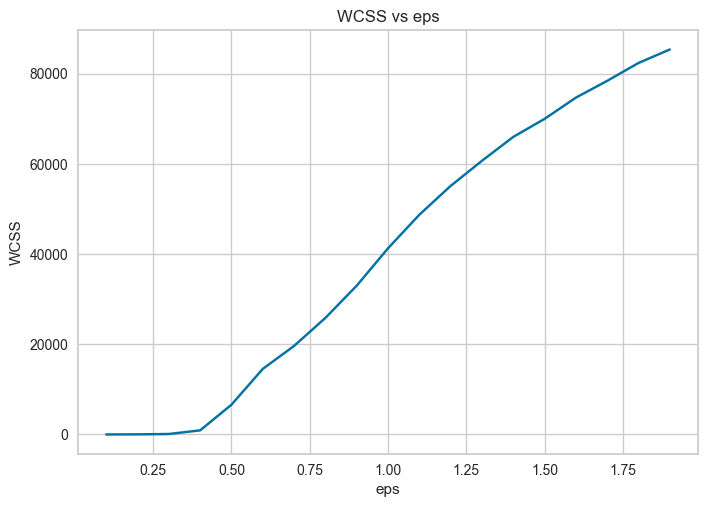

In [157]:
plt.plot(eps_values, wcss_eps)
plt.xlabel('eps')
plt.ylabel('WCSS')
plt.title('WCSS vs eps')
plt.show()

In [158]:
min_samples_values = range(2, 20)
wcss_min = []

In [159]:
for min_samples in min_samples_values:
    db = DBSCAN(eps=0.5, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_
    
    wcss = 0
    for i in set(labels):
        if i != -1:
            cluster = X_scaled[labels == i]
            center = cluster.mean(axis=0)
            wcss += np.sum((cluster - center) ** 2)
    wcss_min.append(wcss)

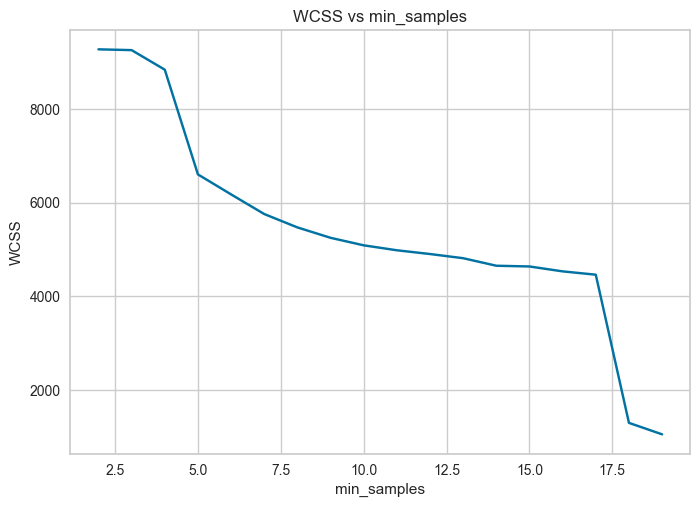

In [160]:
plt.plot(min_samples_values, wcss_min)
plt.xlabel('min_samples')
plt.ylabel('WCSS')
plt.title('WCSS vs min_samples')
plt.show()

WCSS растет с увеличением eps и min_samples. Оптимальные параметры — в точке излома кривой. Для данных лучше подходят малые значения параметров, иначе большинство точек уходит в шум.